In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import * # mae imported

from statsforecast import StatsForecast
from statsforecast.models import ARIMA

from pathlib import Path
import sys

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
    
TARGET_COL = "purchase_bid"  # change to "sell_bid" for sell-side experiments
LAG_SUFFIX = "pb" if TARGET_COL == "purchase_bid" else "sb"
HORIZON = 96 * 7
PARAMS_PATH = Path("data/processed/params/ts_params.json")

from forecasting.data.loaders import load_market_data
from forecasting.features.market import add_daily_clf, add_nci, add_rolling_3d_clf
from forecasting.utils.io import save_json, load_json

from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA, ARIMA, AutoTBATS
from statsforecast.arima import arima_string

In [25]:
indexed_data = load_market_data("../../../data/raw/iex-dam-0201-0421.csv")
data = indexed_data.reset_index()
data.sample()

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
3480,2026-03-09 06:00:00,06:00 - 06:15,19102.7,13185.4,9300.2,5800.84,9300.2


In [26]:
data = data.rename(columns={
    'period_start': 'ds',  # Your timestamp
    TARGET_COL : 'y'             # The target value you want to plot (Market Clearing Price)
})
filtered_data = data[[ "ds", "y" ]].copy()
filtered_data['unique_id'] = 'series_1'
filtered_data["ds"] = pd.to_datetime(filtered_data["ds"])

In [35]:
horizon = 96*7

_market_exog = add_rolling_3d_clf(add_daily_clf(add_nci(indexed_data)))
_rolling_clf = _market_exog[["period_start", "rolling_3d_clf"]].rename(
    columns={"period_start": "ds"}
)

data_with_exog = filtered_data.copy()
data_with_exog = data_with_exog.merge(_rolling_clf, on="ds", how="left")
# data_with_exog["period_enum"] = data_with_exog["ds"].dt.hour * 4 + data_with_exog["ds"].dt.minute // 15 + 1
data_with_exog["weekday_enum"] = data_with_exog["ds"].dt.weekday + 1


test = data_with_exog.groupby("unique_id").tail(horizon)
train = data_with_exog.drop(test.index).reset_index(drop=True)

futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

2026-04-24 18:37:00,435 | INFO | forecasting.features.market | Loading weather master from /Users/dhruvil/Documents/EarthSync/data/weather/weather_master.csv


,ds,unique_id,rolling_3d_clf,weekday_enum
6336,2026-04-08 00:00:00,series_1,1.276933,3
6337,2026-04-08 00:15:00,series_1,1.276933,3
6338,2026-04-08 00:30:00,series_1,1.276933,3
6339,2026-04-08 00:45:00,series_1,1.276933,3
6340,2026-04-08 01:00:00,series_1,1.276933,3


In [36]:
models = [
    ARIMA(order=(0,1,0), season_length=96, seasonal_order=(0, 1, 1), alias="SARIMA (0,1,0,0,1,1,96) exog")
]

sf = StatsForecast(models=models, freq="15min")
sf.fit(df=train)
preds = sf.predict(h=horizon, X_df=futr_exog_df)

test_w_preds = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [37]:
# arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
metrics = evaluate(
    test_w_preds.drop(columns=["weekday_enum", "rolling_3d_clf"]),
    metrics=[mae, rmse, mape],
)
metrics

,unique_id,metric,"SARIMA (0,1,0,0,1,1,96) exog"
0,series_1,mae,2667.719361
1,series_1,rmse,3210.480092
2,series_1,mape,0.185523


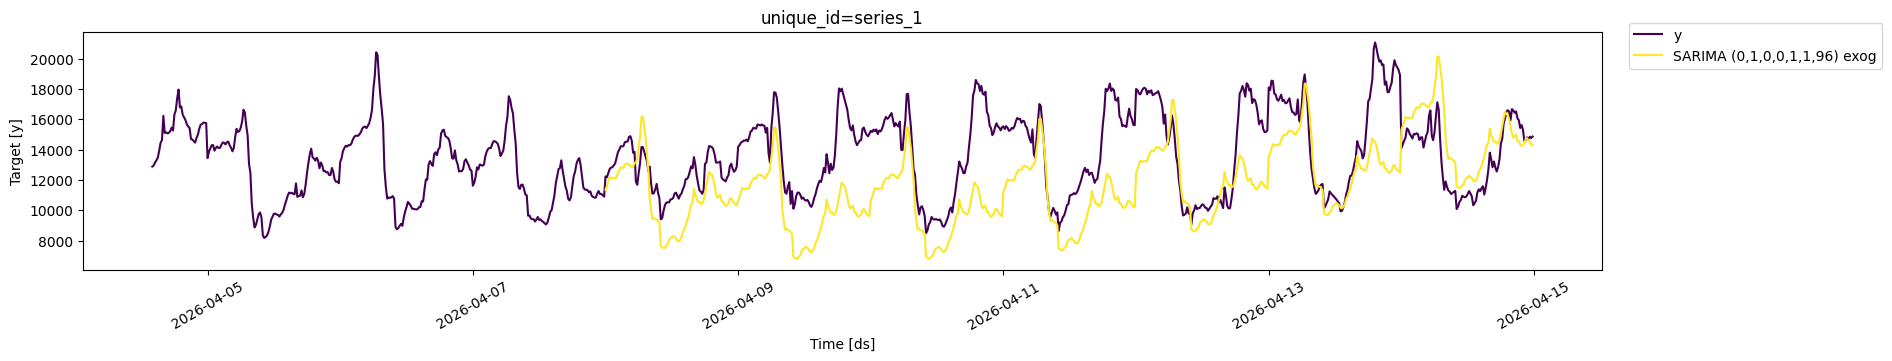

In [38]:
plot_series(
    df=filtered_data, 
    forecasts_df=preds,  
    max_insample_length=1000, 
    palette="viridis")

In [39]:
start_mmdd = preds['ds'].min().strftime('%m%d')
end_mmdd = preds['ds'].max().strftime('%m%d')

to_save = test_w_preds.rename(columns={"SARIMA (0,1,0,0,1,1,96) exog": "pred", "ds": "timestamp"})#.drop(columns=["unique_id", "y", "rolling_3d_clf", "weekday_enum"])
to_save = to_save[["timestamp", "pred"]]

# 3. Construct the filename
filename = f"../../../data/predictions/{LAG_SUFFIX}_timeseries_{start_mmdd}_{end_mmdd}.csv"

# 4. Save to CSV
to_save.to_csv(filename)

print(f"File saved successfully as: {filename}")

File saved successfully as: ../../../data/predictions/pb_timeseries_0408_0414.csv


In [40]:
to_save

,timestamp,pred
0,2026-04-08 00:00:00,11349.672826
1,2026-04-08 00:15:00,11584.815416
2,2026-04-08 00:30:00,11898.728517
3,2026-04-08 00:45:00,12185.181887
4,2026-04-08 01:00:00,12126.931303
...,...,...
667,2026-04-14 22:45:00,14758.526503
668,2026-04-14 23:00:00,14580.447357
669,2026-04-14 23:15:00,14471.524885
670,2026-04-14 23:30:00,14352.737970
